In [82]:
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

import climakitae as ck

In [44]:
# Read CSV files from S3
dfs = []
model_names = ["EC-Earth3", "MIROC6", "MPI-ESM1-2-HR", "TaiESM1"]
for model in model_names:
    url = f"s3://wfclimres/era/hydropower_generation/{model}_weekly_2015-2060_WEAP.csv"
    # Skip first 3 rows (title, scenario, empty row) to get to the actual header
    df = pd.read_csv(url, storage_options={"anon": True}, skiprows=3)
    df["model"] = model
    dfs.append(df)

# Merge all dataframes
merged_df = pd.concat(dfs, ignore_index=True)

# Set multi-index with model and facility name
merged_df = merged_df.set_index(["model", "Hydropower facility"])

# Separate time-series columns from statistics columns
stats_cols = ["Sum", "Min", "Max", "Mean", "Median", "SD", "RMS"]
time_cols = [col for col in merged_df.columns if col not in stats_cols]

# Drop summary rows (these appear as facility-named rows at the bottom of each CSV)
merged_df = merged_df.drop(index=stats_cols, level="Hydropower facility", errors="ignore")

# Extract only the time-series data
timeseries_df = merged_df[time_cols]

# Parse week columns into datetime timestamps
# Column format: "Wk 1 2015" -> start of week 1 in 2015
def parse_week_to_datetime(col_name):
    """Convert 'Wk X YYYY' to datetime (start of that week)"""
    parts = col_name.split()
    week = int(parts[1])
    year = int(parts[2])
    # Week 1 starts on January 1st, subsequent weeks are 7 days apart
    return pd.Timestamp(f"{year}-01-01") + pd.Timedelta(weeks=week-1)

# Create datetime index from column names
time_index = [parse_week_to_datetime(col) for col in timeseries_df.columns]

# Reshape: columns become a time dimension
timeseries_df.columns = time_index

# Stack to long format then convert to xarray
timeseries_df = timeseries_df.stack()
timeseries_df.index.names = ["model", "Hydropower facility", "time"]

# Convert to xarray Dataset with variable named "hydropower"
ds = timeseries_df.to_xarray()
ds = ds.rename({"Hydropower facility": "hydropower"})
ds


<xarray.DataArray (model: 4, hydropower: 216, time: 2392)> Size: 17MB
array([[[ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 2.3107   ,  2.69502  ,  2.88189  , ...,  2.47286  ,
          2.73289  ,  3.06822  ],
        [ 0.338573 ,  0.341839 ,  0.325215 , ...,  0.494757 ,
          0.23628  ,  0.389772 ],
        ...,
        [ 2.03911  ,  0.034879 ,  0.115716 , ..., 16.2583   ,
         16.2583   , 18.5809   ],
        [ 9.16426  ,  7.36033  , 10.438    , ...,  5.23872  ,
          1.69222  ,  1.70679  ],
        [ 0.0599946,  0.0776756,  0.0807663, ...,  1.06351  ,
          1.03152  ,  1.14232  ]],

       [[ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 2.3107   ,  2.69502  ,  2.88189  , ...,  2.36339  ,
          2.60957  ,  2.92757  ],
        [ 0.338573 ,  0.341839 ,  0.325215 , ...,  0.437789 ,
          0.439338 ,  0.390338 ],
...
        [ 2.03911  ,  0.034879 ,  0.115716 , ..., 16.2583   ,
         16.2583   , 18.5809   ],
        [ 9.16426  ,  7.36033  , 10.438    , ...,  6.76076  ,
          6.66821  ,  6.62354  ],
        [ 0.0599946,  0.0776756,  0.0807663, ...,  1.06351  ,
          1.03152  ,  1.14232  ]],

       [[ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 2.3107   ,  2.69502  ,  2.88189  , ...,  2.54892  ,
          2.80514  ,  3.13601  ],
        [ 0.338573 ,  0.341839 ,  0.325215 , ...,  0.428127 ,
          0.510533 ,  0.443151 ],
        ...,
        [ 2.03911  ,  0.034879 ,  0.115716 , ..., 11.4583   ,
         10.8807   , 18.295    ],
        [ 9.16426  ,  7.36033  , 10.438    , ...,  5.74677  ,
          5.63273  ,  5.57529  ],
        [ 0.0599946,  0.0776756,  0.0807663, ...,  1.06351  ,
          1.03152  ,  1.14232  ]]], shape=(4, 216, 2392))
Coordinates:
  * model       (model) object 32B 'EC-Earth3' 'MIROC6' ... 'TaiESM1'
  * hydropower  (hydropower) object 2kB 'Alamo' 'Albeni Falls' ... 'Yelm'
  * time        (time) datetime64[ns] 19kB 2015-01-01 2015-01-08 ... 2060-12-23

In [74]:
# Read Baseline CSV from S3 (same wide format as future model files, single scenario)
url_baseline = "s3://wfclimres/era/hydropower_generation/Baseline_weekly_1980-2020_WEAP.csv"
df_baseline = pd.read_csv(url_baseline, storage_options={"anon": True}, skiprows=3)
df_baseline = df_baseline.set_index("Hydropower facility")

# Drop summary rows
df_baseline = df_baseline.drop(index=stats_cols, errors="ignore")

# Separate time-series columns from statistics columns (reuse stats_cols from above)
time_cols_baseline = [col for col in df_baseline.columns if col not in stats_cols]
df_baseline = df_baseline[time_cols_baseline]

# Coerce values to float
df_baseline = df_baseline.apply(pd.to_numeric, errors="coerce")

# Parse week column names to datetime timestamps (same "Wk X YYYY" format)
time_index_baseline = pd.DatetimeIndex([parse_week_to_datetime(col) for col in df_baseline.columns])
df_baseline.columns = time_index_baseline

# Stack to long format and convert to xarray
stacked_baseline = df_baseline.stack()
stacked_baseline.index.names = ["Hydropower facility", "time"]

ds_baseline = stacked_baseline.to_xarray()
ds_baseline = ds_baseline.rename({"Hydropower facility": "hydropower"})
ds_baseline


<xarray.DataArray (hydropower: 216, time: 2132)> Size: 4MB
array([[ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
         0.       ],
       [ 2.3107   ,  2.69502  ,  2.88189  , ...,  2.57815  ,  2.84223  ,
         3.18376  ],
       [ 0.338573 ,  0.341839 ,  0.325215 , ...,  0.339393 ,  0.297017 ,
         0.274035 ],
       ...,
       [ 2.03911  ,  0.034879 ,  0.115716 , ..., 13.7706   , 16.2583   ,
        18.5809   ],
       [ 9.16426  ,  7.36033  , 10.438    , ...,  7.00103  ,  6.83688  ,
         6.71326  ],
       [ 0.0599946,  0.0776756,  0.0807663, ...,  1.06351  ,  1.03152  ,
         1.14232  ]], shape=(216, 2132))
Coordinates:
  * hydropower  (hydropower) object 2kB 'Alamo' 'Albeni Falls' ... 'Yelm'
  * time        (time) datetime64[ns] 17kB 1980-01-01 1980-01-08 ... 2020-12-23

In [ ]:
# read historical simulations for each model
from pathlib import Path
def parse_week_to_datetime_2(year,week):
    return pd.Timestamp(f"{year}-01-01") + pd.Timedelta(weeks=week-1)

hist_dir = Path("/Users/work/Code/renewable-analysis/notebooks/hydro_generation_data/historical_runs")

hist_dfs = []
for model in model_names:
    file = hist_dir / f"{model}_weekly_1980_2020_WEAP.csv"
    df = pd.read_csv(file, skiprows=5)

    # Build datetime index from Year and Timestep (week number) columns
    time_index = [
        parse_week_to_datetime_2(int(year), int(week))
        for year, week in zip(df["$Columns = Year"], df["Timestep"])
    ]

    # Drop the time-identifier columns; remaining columns are facilities
    facility_df = df.drop(columns=["$Columns = Year", "Timestep"])
    facility_df.index = pd.Index(time_index, name="time")

    # Coerce all values to float (CSV may read scientific notation as strings)
    facility_df = facility_df.apply(pd.to_numeric, errors="coerce")

    # Stack facilities into (time, Hydropower facility) → value
    stacked = facility_df.stack()
    stacked.index.names = ["time", "Hydropower facility"]
    stacked.name = model
    hist_dfs.append(stacked)

# Combine across models and reorder levels to match ds: (model, hydropower, time)
hist_combined = pd.concat(hist_dfs, keys=model_names, names=["model", "time", "Hydropower facility"])
hist_combined = hist_combined.reorder_levels(["model", "Hydropower facility", "time"])

# Convert to xarray matching ds structure
ds_hist = hist_combined.to_xarray()
ds_hist = ds_hist.rename({"Hydropower facility": "hydropower"})
ds_hist


<xarray.DataArray (model: 4, hydropower: 216, time: 2132)> Size: 15MB
array([[[ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 2.3107   ,  2.69502  ,  2.88189  , ...,  2.43555  ,
          2.69194  ,  3.02427  ],
        [ 0.338573 ,  0.341839 ,  0.325215 , ...,  0.335907 ,
          0.2466   ,  0.290142 ],
        ...,
        [ 2.03911  ,  0.034879 ,  0.115716 , ...,  2.37017  ,
          2.21993  ,  2.09111  ],
        [ 9.16426  ,  7.36033  , 10.438    , ...,  1.65071  ,
          1.63206  ,  1.62236  ],
        [ 0.0599946,  0.0776756,  0.0807663, ...,  1.06351  ,
          1.03152  ,  1.09983  ]],

       [[ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 2.3107   ,  2.69502  ,  2.88189  , ...,  2.59939  ,
          2.8692   ,  3.21591  ],
        [ 0.338573 ,  0.341839 ,  0.325215 , ...,  0.467678 ,
          0.461361 ,  0.408045 ],
...
        [ 2.03911  ,  0.034879 ,  0.115716 , ...,  6.50635  ,
          7.69571  ,  6.37338  ],
        [ 9.16426  ,  7.36033  , 10.438    , ...,  3.08949  ,
          3.05186  ,  3.03339  ],
        [ 0.0599946,  0.0776756,  0.0807663, ...,  1.06351  ,
          1.03152  ,  1.14232  ]],

       [[ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 2.3107   ,  2.69502  ,  2.88189  , ...,  2.57042  ,
          2.8364   ,  3.176    ],
        [ 0.338573 ,  0.341839 ,  0.325215 , ...,  0.318752 ,
          0.303281 ,  0.311812 ],
        ...,
        [ 2.03911  ,  0.034879 ,  0.115716 , ..., 16.2583   ,
         16.2583   , 18.5809   ],
        [ 9.16426  ,  7.36033  , 10.438    , ...,  7.73099  ,
          7.62591  ,  7.56784  ],
        [ 0.0599946,  0.0776756,  0.0807663, ...,  1.06351  ,
          1.03152  ,  1.14232  ]]], shape=(4, 216, 2132))
Coordinates:
  * model       (model) object 32B 'EC-Earth3' 'MIROC6' ... 'TaiESM1'
  * hydropower  (hydropower) object 2kB 'Alamo' 'Albeni Falls' ... 'Yelm'
  * time        (time) datetime64[ns] 17kB 1980-01-01 1980-01-08 ... 2020-12-23

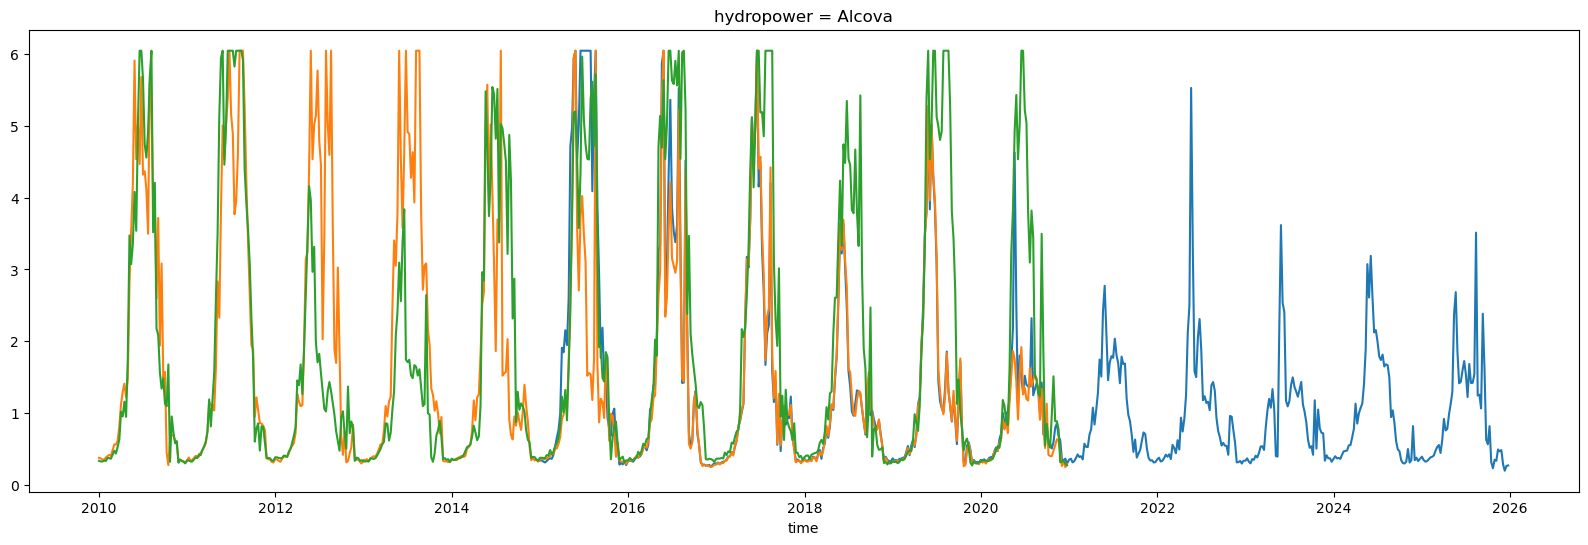

In [76]:
plt.figure(figsize=(20, 6))
ds.sel(model="EC-Earth3", hydropower='Alcova',time=slice('2010','2025')).plot()
ds_hist.sel(model="EC-Earth3", hydropower='Alcova',time=slice('2010','2025')).plot()
ds_baseline.sel(hydropower='Alcova',time=slice('2010','2025')).plot()

In [ ]:
# merge all 
# Step 1: For each model, combine historical (1980-2020) with future (2021+),
# keeping ds_hist values for the overlapping period.
ds_future_only = ds.sel(time=ds.time > ds_hist.time.max())
ds_model_combined = xr.concat([ds_hist, ds_future_only], dim="time")

# Step 2: Add a model dimension to ds_baseline and concat with model runs
ds_baseline_expanded = ds_baseline.expand_dims(model=["Gridmet"])

ds_all = xr.concat([ds_model_combined, ds_baseline_expanded], dim="model")
ds_all = ds_all.rename({"hydropower": "facility"})
ds_all


<xarray.DataArray (model: 5, facility: 216, time: 4212)> Size: 36MB
array([[[ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 2.3107   ,  2.69502  ,  2.88189  , ...,  2.47286  ,
          2.73289  ,  3.06822  ],
        [ 0.338573 ,  0.341839 ,  0.325215 , ...,  0.494757 ,
          0.23628  ,  0.389772 ],
        ...,
        [ 2.03911  ,  0.034879 ,  0.115716 , ..., 16.2583   ,
         16.2583   , 18.5809   ],
        [ 9.16426  ,  7.36033  , 10.438    , ...,  5.23872  ,
          1.69222  ,  1.70679  ],
        [ 0.0599946,  0.0776756,  0.0807663, ...,  1.06351  ,
          1.03152  ,  1.14232  ]],

       [[ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 2.3107   ,  2.69502  ,  2.88189  , ...,  2.36339  ,
          2.60957  ,  2.92757  ],
        [ 0.338573 ,  0.341839 ,  0.325215 , ...,  0.437789 ,
          0.439338 ,  0.390338 ],
...
        [ 2.03911  ,  0.034879 ,  0.115716 , ..., 11.4583   ,
         10.8807   , 18.295    ],
        [ 9.16426  ,  7.36033  , 10.438    , ...,  5.74677  ,
          5.63273  ,  5.57529  ],
        [ 0.0599946,  0.0776756,  0.0807663, ...,  1.06351  ,
          1.03152  ,  1.14232  ]],

       [[ 0.       ,  0.       ,  0.       , ...,        nan,
                nan,        nan],
        [ 2.3107   ,  2.69502  ,  2.88189  , ...,        nan,
                nan,        nan],
        [ 0.338573 ,  0.341839 ,  0.325215 , ...,        nan,
                nan,        nan],
        ...,
        [ 2.03911  ,  0.034879 ,  0.115716 , ...,        nan,
                nan,        nan],
        [ 9.16426  ,  7.36033  , 10.438    , ...,        nan,
                nan,        nan],
        [ 0.0599946,  0.0776756,  0.0807663, ...,        nan,
                nan,        nan]]], shape=(5, 216, 4212))
Coordinates:
  * model     (model) object 40B 'EC-Earth3' 'MIROC6' ... 'TaiESM1' 'Gridmet'
  * facility  (facility) object 2kB 'Alamo' 'Albeni Falls' ... 'Yelm'
  * time      (time) datetime64[ns] 34kB 1980-01-01 1980-01-08 ... 2060-12-23

In [91]:
# save merged data
ds_all.to_netcdf("data/all_WEAP_hydro_generation.nc")

# Visualize facility locations and catchments

255 catchments | 83 Reservoir, 112 RoR facilities


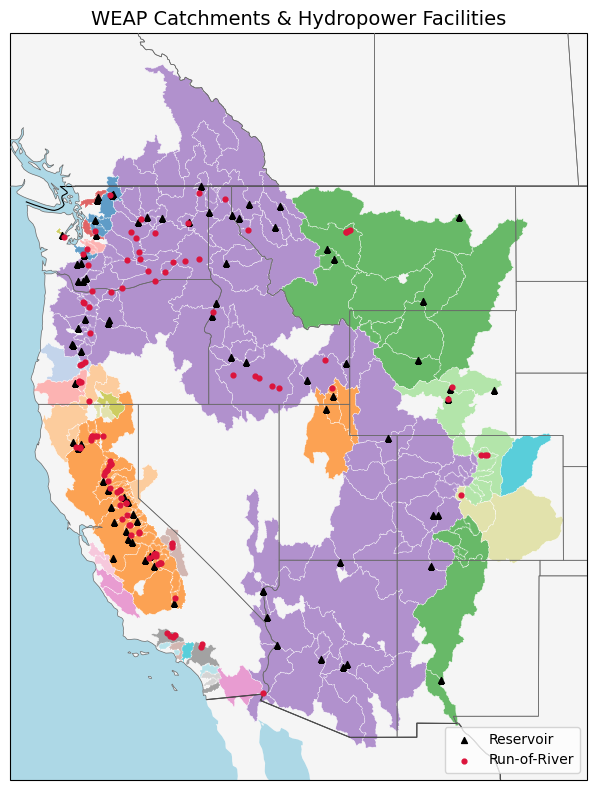

In [90]:
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature

facility_dir = "/Users/work/Code/renewable-analysis/notebooks/hydro_generation_data/facility_locations"

# Load catchment polygons
gdf_catchments = gpd.read_file(f"{facility_dir}/WEAPCatchment.shp").set_crs("EPSG:4326")

# Load facility point locations
df_facilities = pd.read_csv(f"{facility_dir}/WEAP_hydropower_generators_with_avg_annual_generation.csv")
gdf_facilities = gpd.GeoDataFrame(
    df_facilities,
    geometry=gpd.points_from_xy(df_facilities["longitude"], df_facilities["latitude"]),
    crs="EPSG:4326",
)

gdf_reservoir = gdf_facilities[gdf_facilities["RoR_or_Reservoir"] == "Reservoir"]
gdf_ror = gdf_facilities[gdf_facilities["RoR_or_Reservoir"] == "RoR"]
print(f"{len(gdf_catchments)} catchments | {len(gdf_reservoir)} Reservoir, {len(gdf_ror)} RoR facilities")

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": proj})

# Cartopy reference features
ax.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="black", zorder=3)
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor="dimgray", zorder=3)

# Catchment polygons
gdf_catchments.plot(ax=ax, column="BasinID", cmap="tab20", edgecolor="white", linewidth=0.3, alpha=0.7, transform=proj, zorder=2)

# Facilities: Reservoir = filled triangle, RoR = filled circle
gdf_reservoir.plot(ax=ax, color="black", markersize=18, marker="^", zorder=5, label="Reservoir", transform=proj)
gdf_ror.plot(ax=ax, color="crimson", markersize=12, marker="o", zorder=5, label="Run-of-River", transform=proj)

# Extent from catchment bounds with a small buffer
minx, miny, maxx, maxy = gdf_catchments.total_bounds
ax.set_extent([minx - 1, maxx + 1, miny - 1, maxy + 1], crs=proj)

ax.set_title("WEAP Catchments & Hydropower Facilities", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


In CA extent: 98 catchments | 24 Reservoir, 57 RoR facilities


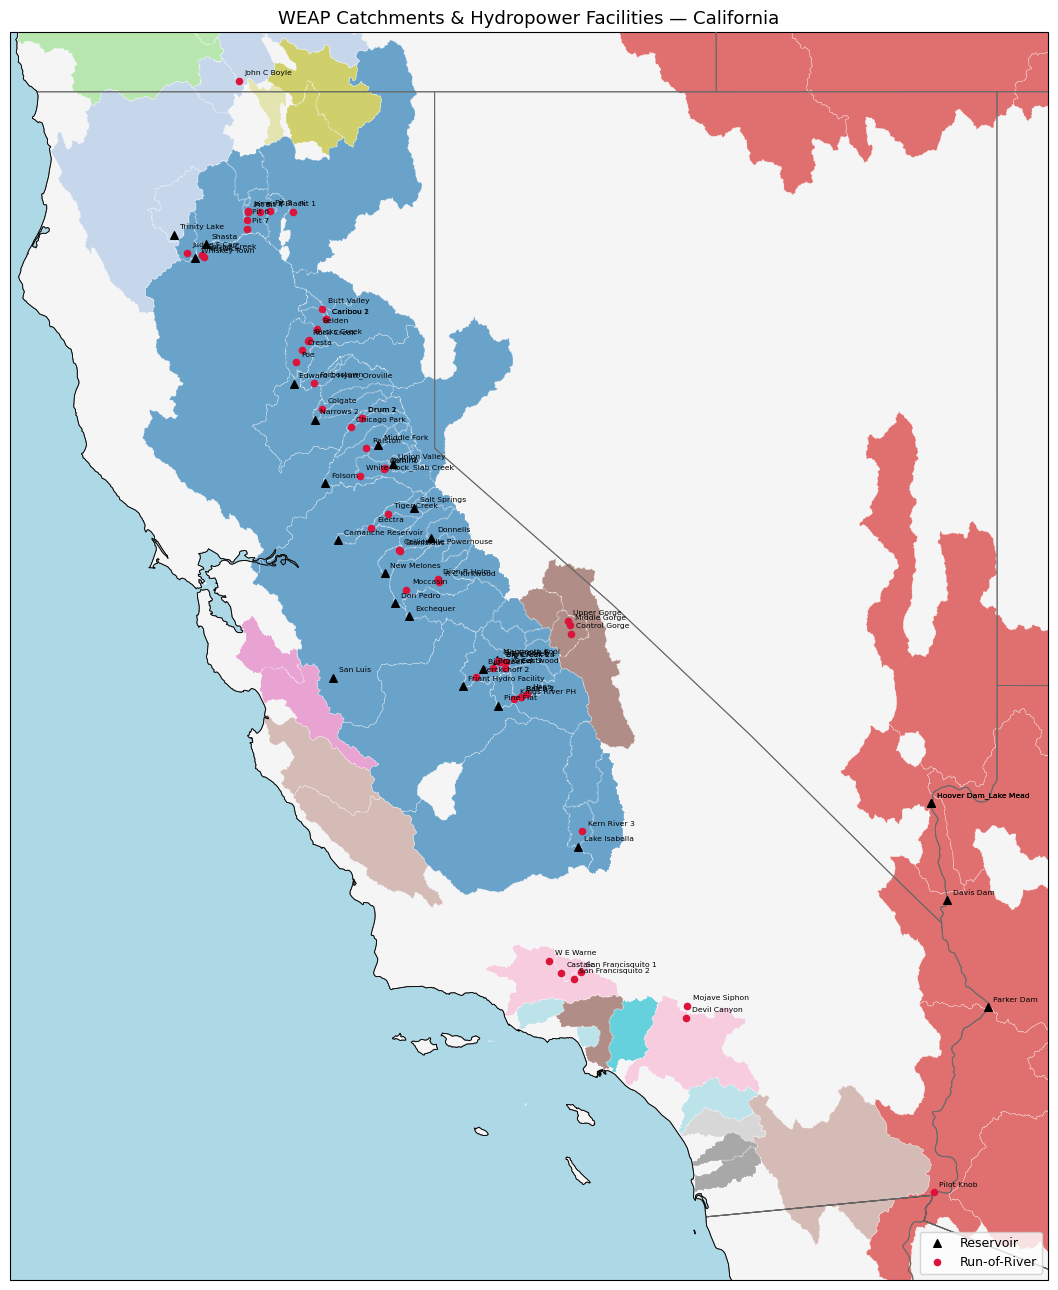

In [92]:

# ── California-zoomed map with facility labels ────────────────────────────
CA_EXTENT = [-124.5, -113.5, 32.0, 42.5]  # [lon_min, lon_max, lat_min, lat_max]

# Clip facilities and catchments to CA extent
gdf_fac_ca = gdf_facilities.cx[CA_EXTENT[0]:CA_EXTENT[1], CA_EXTENT[2]:CA_EXTENT[3]]
gdf_catch_ca = gdf_catchments.cx[CA_EXTENT[0]:CA_EXTENT[1], CA_EXTENT[2]:CA_EXTENT[3]]

gdf_res_ca = gdf_fac_ca[gdf_fac_ca["RoR_or_Reservoir"] == "Reservoir"]
gdf_ror_ca = gdf_fac_ca[gdf_fac_ca["RoR_or_Reservoir"] == "RoR"]
print(f"In CA extent: {len(gdf_catch_ca)} catchments | "
      f"{len(gdf_res_ca)} Reservoir, {len(gdf_ror_ca)} RoR facilities")

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(11, 13), subplot_kw={"projection": proj})

# Background
ax.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="black", zorder=3)
ax.add_feature(cfeature.STATES, linewidth=0.7, edgecolor="dimgray", zorder=3)
ax.coastlines(resolution="10m", linewidth=0.6, zorder=4)

# Catchment polygons
gdf_catch_ca.plot(
    ax=ax, column="BasinID", cmap="tab20",
    edgecolor="white", linewidth=0.3, alpha=0.65,
    transform=proj, zorder=2,
)

# Facility points
gdf_res_ca.plot(ax=ax, color="black",  markersize=30, marker="^", zorder=6, label="Reservoir", transform=proj)
gdf_ror_ca.plot(ax=ax, color="crimson", markersize=20, marker="o", zorder=6, label="Run-of-River", transform=proj)

# Labels — annotate each facility with a small offset
for _, row in gdf_fac_ca.iterrows():
    ax.annotate(
        row["WEAP_name"],
        xy=(row["longitude"], row["latitude"]),
        xytext=(4, 4), textcoords="offset points",
        fontsize=5.5, color="black",
        transform=proj,
        annotation_clip=True,
        zorder=7,
    )

ax.set_extent(CA_EXTENT, crs=proj)
ax.set_title("WEAP Catchments & Hydropower Facilities — California", fontsize=13)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()
